#**Scenario 4**
---
##**MobileNetV2 - Optimizer SGD - Learning Rate 0.0001 - Object Cropping Dataset**

###**Import Dataset**

In [ ]:
#--- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


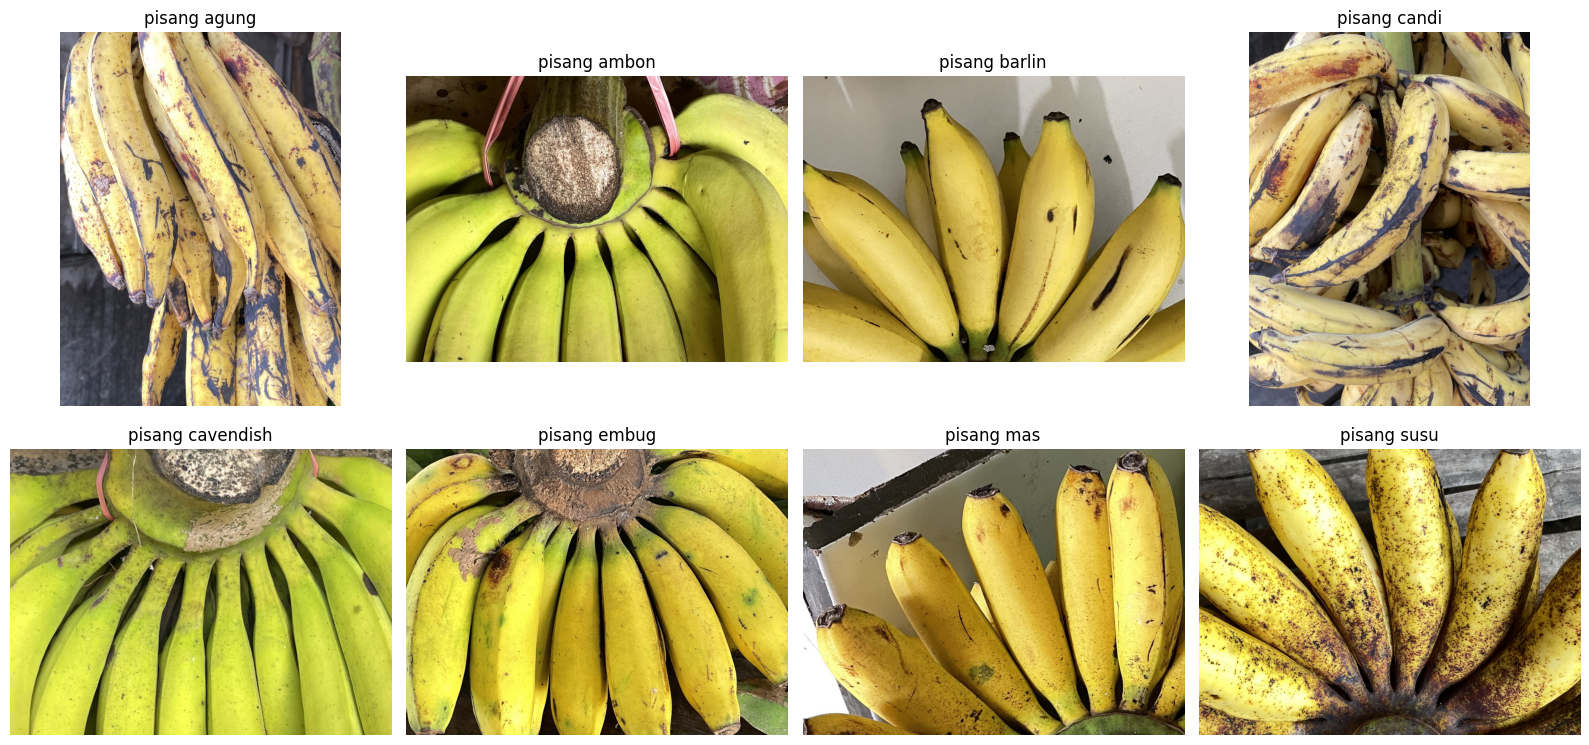

In [ ]:
#--- Display Dataset ---
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/original_dataset/dataset_object_cropping' # lokasi dataset

# Ambil daftar kelas (subfolder)
classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

# Setup figure: 2 baris x 4 kolom
plt.figure(figsize=(16, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    # Ambil satu gambar pertama dari kelas tersebut
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith('.jpg')
    ]

    if len(images) == 0:
        continue

    img_path = os.path.join(class_path, images[0])
    img = Image.open(img_path)

    # Plot
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#--- Cek Jumlah Dataset ---
import os

dataset_split_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_object_cropping'
train_path = os.path.join(dataset_split_path, 'train')
val_path  = os.path.join(dataset_split_path, 'val')

def count_images_per_class(path):
    class_counts = {}
    for class_name in sorted(os.listdir(path)):
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            images = [
                f for f in os.listdir(class_dir)
                if f.lower().endswith('.jpg')
            ]
            class_counts[class_name] = len(images)
    return class_counts

# Hitung jumlah data
train_counts = count_images_per_class(train_path)
val_counts  = count_images_per_class(val_path)

# Tampilkan hasil
print("📊 Jumlah data TRAIN per kelas:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\n📊 Jumlah data VAL per kelas:")
for cls, count in val_counts.items():
    print(f"{cls}: {count}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total VAL :", sum(val_counts.values()))

📊 Jumlah data TRAIN per kelas:
pisang agung: 320
pisang ambon: 320
pisang barlin: 320
pisang candi: 320
pisang cavendish: 320
pisang embug: 320
pisang mas: 320
pisang susu: 320

📊 Jumlah data VAL per kelas:
pisang agung: 80
pisang ambon: 80
pisang barlin: 80
pisang candi: 80
pisang cavendish: 80
pisang embug: 80
pisang mas: 80
pisang susu: 80

Total TRAIN: 2560
Total VAL : 640


###**Preprocessing Dataset**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
train_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_object_cropping/train'
val_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_object_cropping/val'

In [ ]:
#--- Preprocessing Dataset ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # Normalisasi [-1, 1]
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


###**Pemodelan Arsitektur MobileNetV2**

In [ ]:
#--- Load MobileNetV2 ---
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Train ulang semua layer
base_model.trainable = True

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

###**Compile dengan Optimizer SGD dan Learning Rate 0.0001**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.0001,
        momentum=0.9 # Momentum yang umum digunakan
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 2,234,120 (8.52 MB)

 Non-trainable params: 34,112 (133.25 KB)

###**Training Model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#--- Early Stopping untuk mencegah overfitting ---
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

#--- Model Check Point untuk menyimpan model terbaik ---
checkpoint = ModelCheckpoint(
    'best_model_mobilenetv2.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [ ]:
#--- Training model ---
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 899s 11s/step - accuracy: 0.1685 - loss: 2.0384 - val_accuracy: 0.1250 - val_loss: 2.0796
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 621s 8s/step - accuracy: 0.2896 - loss: 1.7576 - val_accuracy: 0.1250 - val_loss: 2.0799
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 613s 8s/step - accuracy: 0.3611 - loss: 1.6435 - val_accuracy: 0.1250 - val_loss: 2.0806
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 614s 8s/step - accuracy: 0.3808 - loss: 1.5822 - val_accuracy: 0.1250 - val_loss: 2.0818
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.4454 - loss: 1.4766 - val_accuracy: 0.1250 - val_loss: 2.0833
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.5410 - loss: 1.3302 - val_accuracy: 0.1250 - val_loss: 2.0855
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 621s 8s/step - accuracy: 0.6048 - loss: 1.1616 - val_accuracy: 0.1250 - val_loss: 2.0880
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 620s 8s/step - accuracy: 0.6383 - loss: 1.0420 - val_accuracy: 0

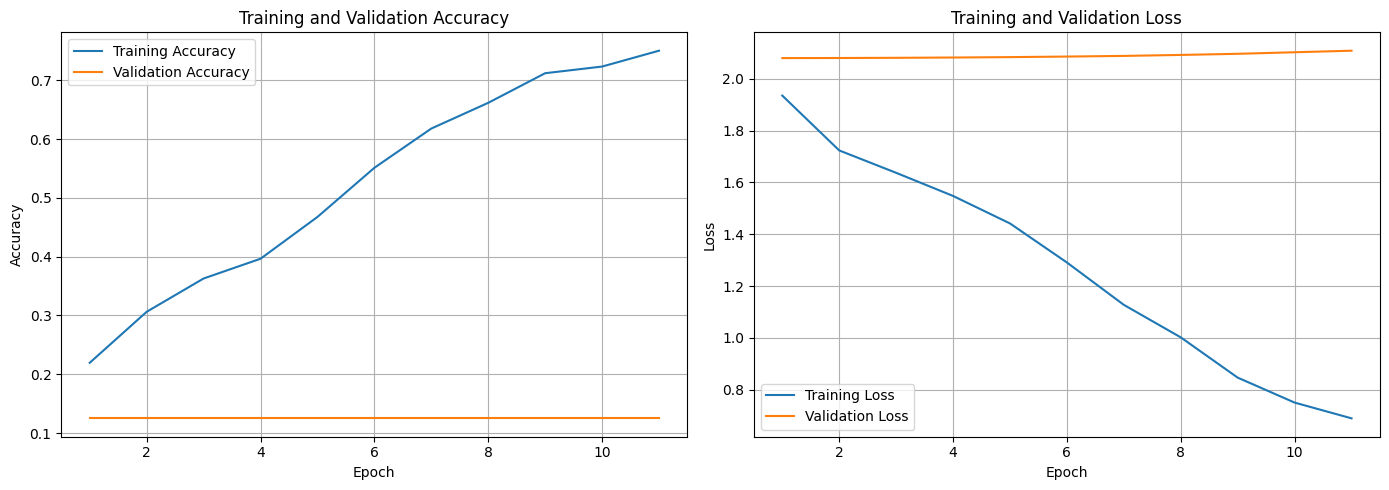

In [ ]:
#--- Menampilkan Grafik Akurasi dan Loss ---
import matplotlib.pyplot as plt

# Ambil data dari history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###**Confussion Matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Prediksi kelas
y_pred_prob = model.predict(val_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label sebenarnya
y_true = val_generator.classes

# Nama kelas
class_names = list(val_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step


In [ ]:
cm = confusion_matrix(y_true, y_pred)

<Figure size 800x800 with 0 Axes>

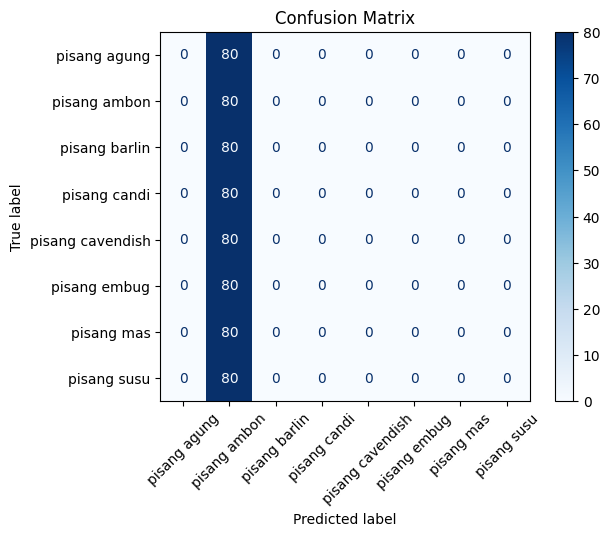

In [ ]:
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

###**Precision, Recall, dan F1-Score**

In [ ]:
from sklearn.metrics import classification_report

# Tampilkan classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

Classification Report:

                  precision    recall  f1-score   support

    pisang agung     0.0000    0.0000    0.0000        80
    pisang ambon     0.1250    1.0000    0.2222        80
   pisang barlin     0.0000    0.0000    0.0000        80
    pisang candi     0.0000    0.0000    0.0000        80
pisang cavendish     0.0000    0.0000    0.0000        80
    pisang embug     0.0000    0.0000    0.0000        80
      pisang mas     0.0000    0.0000    0.0000        80
     pisang susu     0.0000    0.0000    0.0000        80

        accuracy                         0.1250       640
       macro avg     0.0156    0.1250    0.0278       640
    weighted avg     0.0156    0.1250    0.0278       640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
